# Validate And Visualize The Spacing-Aware ACDC Dataset

This notebook checks the ACDC HDF5 dataset that is expected to contain spacing metadata. It is designed for folders produced by `scripts/convert_acdc_nifti_to_h5.py`, such as `outputs/acdc_h5_with_metadata`, and it can also inspect preprocessed spacing-aware folders such as `outputs/acdc_preprocessed_2d_spacing` or `outputs/acdc_preprocessed_3d_spacing`.

The main goal is to catch quiet dataset problems before training: missing spacing, inconsistent image/label shapes, invalid labels, non-finite image values, duplicate patient/frame entries, suspicious physical field of view, and visually bad label alignment.


In [12]:
from pathlib import Path
import re
import warnings

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.precision", 4)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Change this if your spacing-aware dataset lives somewhere else.
DATA_ROOT = PROJECT_ROOT / "outputs" / "acdc_h5_with_metadata"

# Useful alternatives:
# DATA_ROOT = PROJECT_ROOT / "outputs" / "acdc_preprocessed_2d_spacing" / "unet2d"
# DATA_ROOT = PROJECT_ROOT / "outputs" / "acdc_preprocessed_2d_spacing" / "fcn8"
# DATA_ROOT = PROJECT_ROOT / "outputs" / "acdc_preprocessed_3d_spacing"
# DATA_ROOT = PROJECT_ROOT / "ACDC_preprocessed"  # should fail spacing checks

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATA_ROOT}")
print(f"Dataset root exists: {DATA_ROOT.exists()}")


Project root: /home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge
Dataset root: /home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge/outputs/acdc_h5_with_metadata
Dataset root exists: True


## Discover HDF5 Files

The scanner is intentionally permissive: it can inspect raw converted volumes/slices and spacing-aware preprocessed files. It records both structural information and metadata attributes for every `.h5` file.


In [13]:
SPACING_KEYS = ["spacing_zyx", "target_spacing_zyx", "source_spacing_zyx"]
REQUIRED_DATASETS = ["image"]
OPTIONAL_DATASETS = ["label", "scribble"]
EXPECTED_LABELS = {0, 1, 2, 3}
CLASS_NAMES = {0: "background", 1: "RV", 2: "Myo", 3: "LV"}


def parse_identity(path):
    name = path.stem
    if name.endswith(".nii"):
        name = name[:-4]
    parts = name.split("_")
    patient = None
    frame = None
    slice_index = None
    for part in parts:
        if part.startswith("patient"):
            try:
                patient = int(part.replace("patient", ""))
            except ValueError:
                pass
        elif part.startswith("frame"):
            try:
                frame = int(part.replace("frame", ""))
            except ValueError:
                pass
    if "slice" in parts:
        idx = parts.index("slice")
        if idx + 1 < len(parts):
            try:
                slice_index = int(re.sub(r"\D+$", "", parts[idx + 1]))
            except ValueError:
                pass
    return patient, frame, slice_index


def attr_value(attrs, key):
    if key not in attrs:
        return None
    value = attrs[key]
    if isinstance(value, bytes):
        return value.decode("utf-8", errors="replace")
    if isinstance(value, np.ndarray):
        return value.tolist()
    if hasattr(value, "item"):
        try:
            return value.item()
        except Exception:
            return value
    return value


def spacing_from_attrs(attrs):
    for key in SPACING_KEYS:
        if key in attrs:
            spacing = np.asarray(attrs[key], dtype=float).reshape(-1)
            return key, spacing
    return None, None


def scan_h5_file(path):
    patient_from_name, frame_from_name, slice_from_name = parse_identity(path)
    row = {
        "path": path,
        "rel_path": path.relative_to(PROJECT_ROOT).as_posix() if path.is_relative_to(PROJECT_ROOT) else path.as_posix(),
        "folder": path.parent.name,
        "patient_from_name": patient_from_name,
        "frame_from_name": frame_from_name,
        "slice_from_name": slice_from_name,
    }
    issues = []

    try:
        with h5py.File(path, "r") as h5:
            keys = set(h5.keys())
            row["datasets"] = sorted(keys)
            for dataset in REQUIRED_DATASETS:
                if dataset not in keys:
                    issues.append(f"missing dataset: {dataset}")

            image = h5["image"] if "image" in h5 else None
            if image is not None:
                row["image_shape"] = tuple(image.shape)
                row["image_ndim"] = image.ndim
                row["image_dtype"] = str(image.dtype)
                image_sample = image[:]
                row["image_min"] = float(np.nanmin(image_sample))
                row["image_max"] = float(np.nanmax(image_sample))
                row["image_mean"] = float(np.nanmean(image_sample))
                row["image_std"] = float(np.nanstd(image_sample))
                row["image_finite"] = bool(np.isfinite(image_sample).all())
                if not row["image_finite"]:
                    issues.append("image contains NaN or Inf")
                if image.ndim not in (2, 3):
                    issues.append(f"unexpected image ndim: {image.ndim}")

            for dataset in OPTIONAL_DATASETS:
                row[f"has_{dataset}"] = dataset in keys
                if dataset in keys:
                    arr = h5[dataset]
                    row[f"{dataset}_shape"] = tuple(arr.shape)
                    row[f"{dataset}_dtype"] = str(arr.dtype)
                    if image is not None and tuple(arr.shape) != tuple(image.shape):
                        issues.append(f"{dataset} shape does not match image")

            if "label" in keys:
                label = h5["label"][:]
                unique = sorted(int(v) for v in np.unique(label))
                row["label_values"] = unique
                row["label_foreground_voxels"] = int((label > 0).sum())
                row["label_foreground_fraction"] = float((label > 0).mean())
                unexpected = sorted(set(unique) - EXPECTED_LABELS)
                missing_known = sorted(EXPECTED_LABELS - set(unique))
                row["unexpected_label_values"] = unexpected
                row["missing_label_values"] = missing_known
                if unexpected:
                    issues.append(f"unexpected label values: {unexpected}")
                for class_id, class_name in CLASS_NAMES.items():
                    row[f"label_{class_name}_voxels"] = int((label == class_id).sum())

            spacing_key, spacing = spacing_from_attrs(h5.attrs)
            row["spacing_key_used"] = spacing_key
            row["has_spacing"] = spacing is not None
            if spacing is None:
                issues.append("missing spacing metadata")
            else:
                row["spacing_zyx"] = tuple(float(v) for v in spacing)
                row["spacing_z"] = float(spacing[0]) if len(spacing) > 0 else np.nan
                row["spacing_y"] = float(spacing[1]) if len(spacing) > 1 else np.nan
                row["spacing_x"] = float(spacing[2]) if len(spacing) > 2 else np.nan
                if len(spacing) != 3:
                    issues.append(f"spacing length is {len(spacing)}, expected 3")
                if not np.isfinite(spacing).all() or np.any(spacing <= 0):
                    issues.append(f"spacing must be positive finite values: {spacing}")
                if image is not None and len(spacing) == 3:
                    shape = np.asarray(image.shape, dtype=float)
                    if image.ndim == 2:
                        row["physical_height_mm"] = float(shape[0] * spacing[1])
                        row["physical_width_mm"] = float(shape[1] * spacing[2])
                    elif image.ndim == 3:
                        row["physical_depth_mm"] = float(shape[0] * spacing[0])
                        row["physical_height_mm"] = float(shape[1] * spacing[1])
                        row["physical_width_mm"] = float(shape[2] * spacing[2])

            attrs_to_copy = [
                "source_path", "shape_zyx", "source_spacing_zyx", "target_spacing_zyx",
                "spacing_xyz", "phase", "diagnosis", "patient_id", "frame",
                "target_height", "target_width", "target_depth", "normalization_mean",
                "normalization_std", "preprocessing",
            ]
            for key in attrs_to_copy:
                row[key] = attr_value(h5.attrs, key)

            if row.get("patient_id") is None:
                row["patient_id"] = patient_from_name
            if row.get("frame") is None:
                row["frame"] = frame_from_name

            if image is not None and row.get("shape_zyx") is not None:
                shape_attr = tuple(int(v) for v in np.asarray(row["shape_zyx"]).reshape(-1))
                if image.ndim == 3 and tuple(image.shape) != shape_attr:
                    # This is expected for preprocessed outputs that keep original shape_zyx as source metadata.
                    row["shape_attr_matches_image"] = False
                elif image.ndim == 2 and len(shape_attr) >= 2 and tuple(image.shape) != shape_attr[-2:]:
                    row["shape_attr_matches_image"] = False
                else:
                    row["shape_attr_matches_image"] = True

    except Exception as exc:
        issues.append(f"failed to read file: {type(exc).__name__}: {exc}")

    row["issue_count"] = len(issues)
    row["issues"] = "; ".join(issues)
    return row


files = sorted(DATA_ROOT.rglob("*.h5")) if DATA_ROOT.exists() else []
print(f"HDF5 files found: {len(files)}")
if not files:
    print("No files found. Generate the spacing-aware dataset first, or update DATA_ROOT above.")

manifest = pd.DataFrame([scan_h5_file(path) for path in files]) if files else pd.DataFrame()
if not manifest.empty:
    display(manifest.head())


HDF5 files found: 2886


,path,rel_path,folder,patient_from_name,frame_from_name,slice_from_name,datasets,image_shape,image_ndim,image_dtype,image_min,image_max,image_mean,image_std,image_finite,has_label,label_shape,label_dtype,has_scribble,label_values,label_foreground_voxels,label_foreground_fraction,unexpected_label_values,missing_label_values,label_background_voxels,label_RV_voxels,label_Myo_voxels,label_LV_voxels,spacing_key_used,has_spacing,spacing_zyx,spacing_z,spacing_y,spacing_x,physical_height_mm,physical_width_mm,source_path,shape_zyx,source_spacing_zyx,target_spacing_zyx,spacing_xyz,phase,diagnosis,patient_id,frame,target_height,target_width,target_depth,normalization_mean,normalization_std,preprocessing,shape_attr_matches_image,issue_count,issues,physical_depth_mm
0,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,ACDC_testing_slices,102,1,0.0,"[image, label]","(256, 216)",2,float32,10.0,218.0,54.8792,39.0775,True,True,"(256, 216)",uint8,False,"[0, 1, 2, 3]",1974,0.0357,[],[],53322,1010,512,452,spacing_zyx,True,"(10.0, 1.5625, 1.5625)",10.0,1.5625,1.5625,400.0,337.5,testing/patient102/patient102_frame01.nii.gz,"[8, 256, 216]",None,None,"[1.5625, 1.5625, 10.0]",ED,NOR,patient102,1,None,None,None,None,None,None,True,0,,NaN
1,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,ACDC_testing_slices,102,1,1.0,"[image, label]","(256, 216)",2,float32,10.0,227.0,54.9722,39.0583,True,True,"(256, 216)",uint8,False,"[0, 1, 2, 3]",2201,0.0398,[],[],53095,1089,587,525,spacing_zyx,True,"(10.0, 1.5625, 1.5625)",10.0,1.5625,1.5625,400.0,337.5,testing/patient102/patient102_frame01.nii.gz,"[8, 256, 216]",None,None,"[1.5625, 1.5625, 10.0]",ED,NOR,patient102,1,None,None,None,None,None,None,True,0,,NaN
2,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,ACDC_testing_slices,102,1,2.0,"[image, label]","(256, 216)",2,float32,8.0,187.0,54.4863,39.0733,True,True,"(256, 216)",uint8,False,"[0, 1, 2, 3]",1994,0.0361,[],[],53302,840,574,580,spacing_zyx,True,"(10.0, 1.5625, 1.5625)",10.0,1.5625,1.5625,400.0,337.5,testing/patient102/patient102_frame01.nii.gz,"[8, 256, 216]",None,None,"[1.5625, 1.5625, 10.0]",ED,NOR,patient102,1,None,None,None,None,None,None,True,0,,NaN
3,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,ACDC_testing_slices,102,1,3.0,"[image, label]","(256, 216)",2,float32,8.0,217.0,53.4109,39.4596,True,True,"(256, 216)",uint8,False,"[0, 1, 2, 3]",1645,0.0297,[],[],53651,548,489,608,spacing_zyx,True,"(10.0, 1.5625, 1.5625)",10.0,1.5625,1.5625,400.0,337.5,testing/patient102/patient102_frame01.nii.gz,"[8, 256, 216]",None,None,"[1.5625, 1.5625, 10.0]",ED,NOR,patient102,1,None,None,None,None,None,None,True,0,,NaN
4,/home/basic/Faks/Automated-Cardiac-Diagnosis-C...,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,ACDC_testing_slices,102,1,4.0,"[image, label]","(256, 216)",2,float32,7.0,199.0,52.9926,39.3181,True,True,"(256, 216)",uint8,False,"[0, 1, 2, 3]",1201,0.0217,[],[],54095,327,337,537,spacing_zyx,True,"(10.0, 1.5625, 1.5625)",10.0,1.5625,1.5625,400.0,337.5,testing/patient102/patient102_frame01.nii.gz,"[8, 256, 216]",None,None,"[1.5625, 1.5625, 10.0]",ED,NOR,patient102,1,None,None,None,None,None,None,True,0,,NaN


## High-Level Dataset Summary

In [14]:
if manifest.empty:
    print("No manifest to summarize.")
else:
    summary = {
        "files": len(manifest),
        "patients": manifest["patient_id"].nunique(dropna=True) if "patient_id" in manifest else None,
        "frames": manifest[["patient_id", "frame"]].dropna().drop_duplicates().shape[0] if {"patient_id", "frame"}.issubset(manifest.columns) else None,
        "files_with_spacing": int(manifest["has_spacing"].sum()),
        "files_missing_spacing": int((~manifest["has_spacing"]).sum()),
        "files_with_label": int(manifest.get("has_label", pd.Series(dtype=bool)).fillna(False).sum()),
        "files_with_issues": int((manifest["issue_count"] > 0).sum()),
    }
    display(pd.DataFrame([summary]))

    by_folder = manifest.groupby("folder", dropna=False).agg(
        files=("path", "count"),
        patients=("patient_id", "nunique"),
        spacing_missing=("has_spacing", lambda s: int((~s).sum())),
        labeled=("has_label", lambda s: int(s.fillna(False).sum())),
        issue_files=("issue_count", lambda s: int((s > 0).sum())),
    ).reset_index().sort_values("folder")
    display(by_folder)


,files,patients,frames,files_with_spacing,files_missing_spacing,files_with_label,files_with_issues
0,2886,132,264,2886,0,2886,0


,folder,files,patients,spacing_missing,labeled,issue_files
0,ACDC_testing_slices,720,32,0,720,0
1,ACDC_testing_volumes,64,32,0,64,0
2,ACDC_training_slices,1902,100,0,1902,0
3,ACDC_training_volumes,200,100,0,200,0


## Validity Report

This section lists every file with one or more issues. For a healthy spacing-aware dataset, `missing spacing metadata` should not appear.


In [15]:
if manifest.empty:
    print("No validation report because no files were found.")
else:
    issue_table = manifest.loc[manifest["issue_count"] > 0, [
        "rel_path", "image_shape", "has_spacing", "spacing_zyx", "has_label", "label_values", "issues"
    ]].copy()
    if issue_table.empty:
        print("No file-level issues found.")
    else:
        print(f"Files with issues: {len(issue_table)} / {len(manifest)}")
        display(issue_table)


No file-level issues found.


## Spacing And Shape Checks

,spacing_z,spacing_y,spacing_x
count,2886.0000,2886.0000,2886.0000
mean,8.8437,1.5319,1.5319
std,2.0864,0.1762,0.1762
min,5.0000,0.7031,0.7031
25%,10.0000,1.3672,1.3672
50%,10.0000,1.5625,1.5625
75%,10.0000,1.6797,1.6797
max,10.0000,1.9531,1.9531


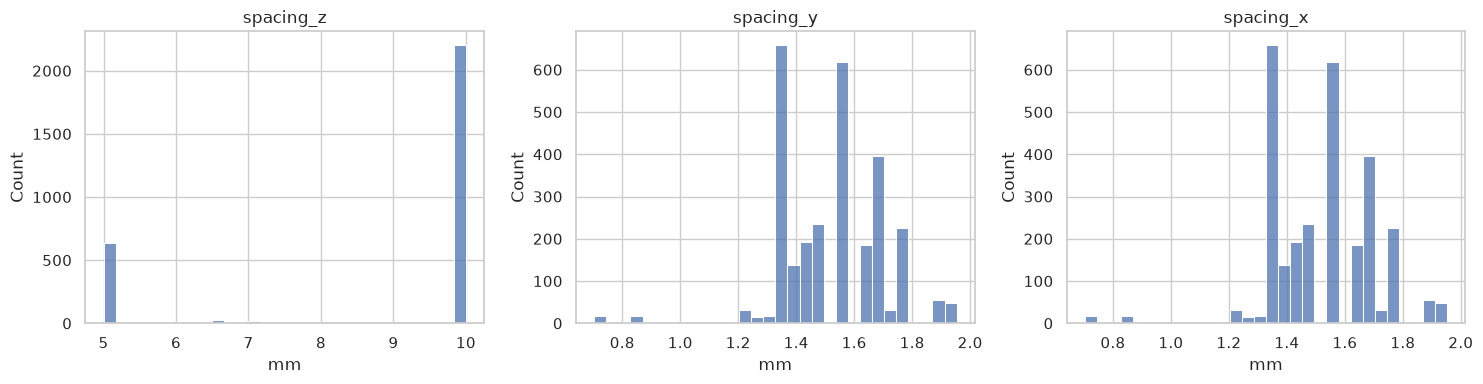

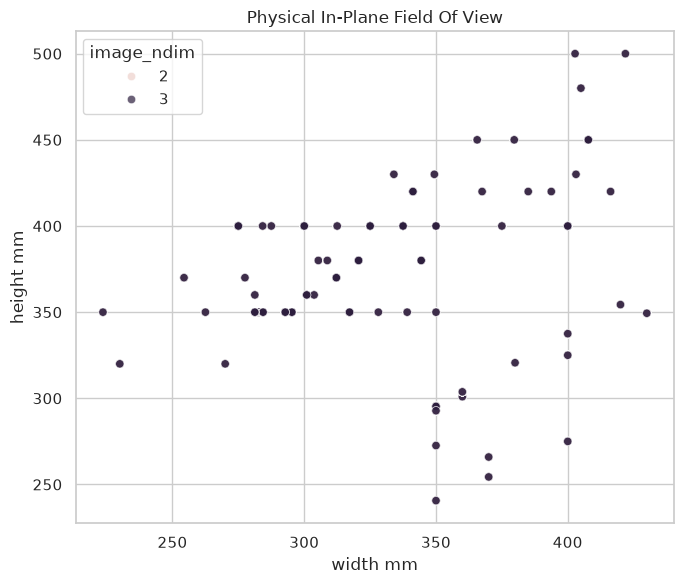

In [16]:
if manifest.empty or "has_spacing" not in manifest:
    print("No spacing data to plot.")
else:
    spaced = manifest[manifest["has_spacing"]].copy()
    if spaced.empty:
        print("No files have spacing metadata.")
    else:
        spacing_cols = ["spacing_z", "spacing_y", "spacing_x"]
        display(spaced[spacing_cols].describe())

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        for ax, col in zip(axes, spacing_cols):
            sns.histplot(spaced[col], bins=30, ax=ax)
            ax.set_title(col)
            ax.set_xlabel("mm")
        plt.tight_layout()

        if {"physical_height_mm", "physical_width_mm"}.issubset(spaced.columns):
            plt.figure(figsize=(7, 6))
            sns.scatterplot(
                data=spaced,
                x="physical_width_mm",
                y="physical_height_mm",
                hue="image_ndim",
                alpha=0.7,
            )
            plt.title("Physical In-Plane Field Of View")
            plt.xlabel("width mm")
            plt.ylabel("height mm")
            plt.tight_layout()


## Label Checks

,label_foreground_fraction,label_background_voxels,label_RV_voxels,label_Myo_voxels,label_LV_voxels
count,2886.0000,2.8860e+03,2886.0000,2886.0000,2886.0000
mean,0.0378,9.1760e+04,1181.4615,1206.0326,1192.0326
std,0.0221,1.3822e+05,2240.7601,2026.1321,2173.7213
min,0.0000,3.1240e+04,0.0000,0.0000,0.0000
25%,0.0219,4.6844e+04,142.0000,392.0000,275.0000
50%,0.0363,5.2700e+04,608.5000,650.0000,620.0000
75%,0.0526,5.5296e+04,1235.7500,990.0000,1102.7500
max,0.1138,1.6916e+06,28165.0000,29696.0000,23799.0000


,rel_path,label_values,label_foreground_voxels,unexpected_label_values
7,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
8,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
15,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
25,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
34,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
44,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
45,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
53,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
64,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]
65,outputs/acdc_h5_with_metadata/ACDC_testing_sli...,[0],0,[]


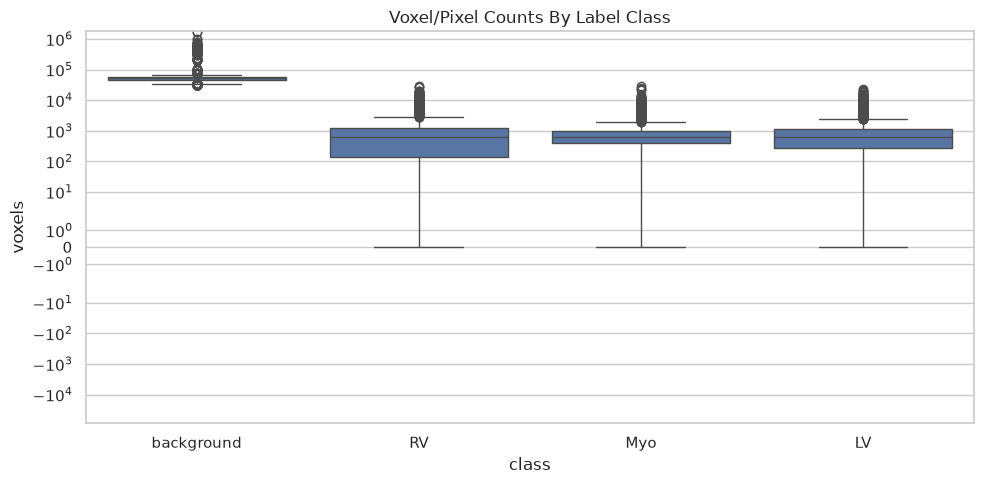

In [17]:
if manifest.empty or "has_label" not in manifest:
    print("No labels found in manifest.")
else:
    labeled = manifest[manifest["has_label"].fillna(False)].copy()
    if labeled.empty:
        print("No labeled files found.")
    else:
        label_summary_cols = [
            "label_foreground_fraction",
            "label_background_voxels",
            "label_RV_voxels",
            "label_Myo_voxels",
            "label_LV_voxels",
        ]
        label_summary_cols = [c for c in label_summary_cols if c in labeled.columns]
        display(labeled[label_summary_cols].describe())

        melted = labeled[["rel_path", *[c for c in label_summary_cols if c.endswith("_voxels")]]].melt(
            id_vars="rel_path", var_name="class", value_name="voxels"
        )
        melted["class"] = melted["class"].str.replace("label_", "", regex=False).str.replace("_voxels", "", regex=False)
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=melted, x="class", y="voxels")
        plt.yscale("symlog")
        plt.title("Voxel/Pixel Counts By Label Class")
        plt.tight_layout()

        suspicious = labeled[
            (labeled["label_foreground_voxels"] == 0)
            | (labeled["unexpected_label_values"].map(lambda values: len(values) > 0 if isinstance(values, list) else False))
        ]
        if suspicious.empty:
            print("No empty-foreground or unexpected-label files found.")
        else:
            display(suspicious[["rel_path", "label_values", "label_foreground_voxels", "unexpected_label_values"]])


## Patient, Frame, Phase, And Diagnosis Checks

In [18]:
if manifest.empty:
    print("No patient/frame information to inspect.")
else:
    identity_cols = [c for c in ["patient_id", "frame", "phase", "diagnosis", "folder", "rel_path"] if c in manifest.columns]
    display(manifest[identity_cols].head())

    if {"patient_id", "frame"}.issubset(manifest.columns):
        per_patient = manifest.dropna(subset=["patient_id", "frame"]).groupby("patient_id").agg(
            files=("path", "count"),
            frames=("frame", "nunique"),
            first_frame=("frame", "min"),
            last_frame=("frame", "max"),
        ).reset_index()
        display(per_patient.describe())
        display(per_patient.head(20))

        duplicate_rows = manifest[manifest.duplicated(["folder", "patient_id", "frame", "slice_from_name"], keep=False)]
        if duplicate_rows.empty:
            print("No duplicate folder/patient/frame/slice identities found.")
        else:
            print("Potential duplicate identities:")
            display(duplicate_rows[["folder", "patient_id", "frame", "slice_from_name", "rel_path"]].sort_values(["patient_id", "frame", "slice_from_name"]))

    if "phase" in manifest:
        display(manifest["phase"].fillna("missing").value_counts().rename_axis("phase").to_frame("files"))
    if "diagnosis" in manifest:
        display(manifest["diagnosis"].fillna("missing").value_counts().rename_axis("diagnosis").to_frame("files"))


,patient_id,frame,phase,diagnosis,folder,rel_path
0,patient102,1,ED,NOR,ACDC_testing_slices,outputs/acdc_h5_with_metadata/ACDC_testing_sli...
1,patient102,1,ED,NOR,ACDC_testing_slices,outputs/acdc_h5_with_metadata/ACDC_testing_sli...
2,patient102,1,ED,NOR,ACDC_testing_slices,outputs/acdc_h5_with_metadata/ACDC_testing_sli...
3,patient102,1,ED,NOR,ACDC_testing_slices,outputs/acdc_h5_with_metadata/ACDC_testing_sli...
4,patient102,1,ED,NOR,ACDC_testing_slices,outputs/acdc_h5_with_metadata/ACDC_testing_sli...


,files,frames,first_frame,last_frame
count,132.0000,132.0,132.0000,132.0000
mean,21.8636,2.0,1.0227,10.7348
std,5.6525,0.0,0.2611,2.2305
min,14.0000,2.0,1.0000,6.0000
25%,18.0000,2.0,1.0000,9.0000
50%,22.0000,2.0,1.0000,11.0000
75%,22.0000,2.0,1.0000,12.0000
max,44.0000,2.0,4.0000,16.0000


,patient_id,files,frames,first_frame,last_frame
0,patient001,22,2,1,12
1,patient002,22,2,1,12
2,patient003,22,2,1,15
3,patient004,22,2,1,15
4,patient005,22,2,1,13
5,patient006,24,2,1,16
6,patient007,22,2,1,7
7,patient008,22,2,1,13
8,patient009,22,2,1,13
9,patient010,22,2,1,13


No duplicate folder/patient/frame/slice identities found.


,files
phase,
ED,1443
ES,1443


,files
diagnosis,
RV,734
HCM,586
DCM,582
NOR,512
MINF,472


## Visual Inspection Helpers

In [19]:
LABEL_COLORS = np.array([
    [0.0, 0.0, 0.0, 0.0],      # background transparent
    [0.1, 0.45, 1.0, 0.45],    # RV
    [1.0, 0.75, 0.05, 0.45],   # Myo
    [1.0, 0.1, 0.1, 0.45],     # LV
])


def load_image_label(path):
    with h5py.File(path, "r") as h5:
        image = h5["image"][:]
        label = h5["label"][:] if "label" in h5 else None
        attrs = {key: attr_value(h5.attrs, key) for key in h5.attrs.keys()}
    return image, label, attrs


def normalize_for_display(image):
    image = image.astype(float)
    low, high = np.percentile(image[np.isfinite(image)], [1, 99]) if np.isfinite(image).any() else (0, 1)
    if high <= low:
        return np.zeros_like(image, dtype=float)
    return np.clip((image - low) / (high - low), 0, 1)


def slice_2d(array, index=None):
    if array is None:
        return None
    if array.ndim == 2:
        return array
    if index is None:
        index = array.shape[0] // 2
    return array[index]


def show_case(path, slice_index=None):
    image, label, attrs = load_image_label(path)
    if image.ndim == 3 and slice_index is None:
        slice_index = image.shape[0] // 2
    image2d = slice_2d(image, slice_index)
    label2d = slice_2d(label, slice_index)

    fig, axes = plt.subplots(1, 3 if label2d is not None else 1, figsize=(15, 5))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])

    axes[0].imshow(normalize_for_display(image2d), cmap="gray")
    axes[0].set_title("image")
    axes[0].axis("off")

    if label2d is not None:
        axes[1].imshow(label2d, interpolation="nearest", vmin=0, vmax=3)
        axes[1].set_title("label")
        axes[1].axis("off")

        axes[2].imshow(normalize_for_display(image2d), cmap="gray")
        overlay = LABEL_COLORS[np.clip(label2d.astype(int), 0, len(LABEL_COLORS) - 1)]
        axes[2].imshow(overlay, interpolation="nearest")
        axes[2].set_title("overlay")
        axes[2].axis("off")

    title = path.name
    if image.ndim == 3:
        title += f" | slice {slice_index}/{image.shape[0] - 1}"
    if "spacing_zyx" in attrs:
        title += f" | spacing_zyx={attrs['spacing_zyx']}"
    fig.suptitle(title)
    plt.tight_layout()
    return fig


## Visualize One Case

In [20]:
if manifest.empty:
    print("No files available for visualization.")
else:
    candidates = manifest[manifest.get("has_label", False).fillna(False)] if "has_label" in manifest else manifest
    if candidates.empty:
        candidates = manifest
    options = [(row.rel_path, row.path) for row in candidates.itertuples()]

    if widgets is None:
        selected_path = options[0][1]
        print(f"ipywidgets unavailable. Showing: {selected_path}")
        show_case(selected_path)
    else:
        dropdown = widgets.Dropdown(options=options, description="file:", layout=widgets.Layout(width="900px"))
        slider = widgets.IntSlider(value=0, min=0, max=0, description="slice:")
        out = widgets.Output()

        def update_slider(*_):
            image, _, _ = load_image_label(dropdown.value)
            if image.ndim == 3:
                slider.max = image.shape[0] - 1
                slider.value = image.shape[0] // 2
                slider.disabled = False
            else:
                slider.max = 0
                slider.value = 0
                slider.disabled = True

        def render(*_):
            with out:
                out.clear_output(wait=True)
                show_case(dropdown.value, slider.value)
                plt.show()

        dropdown.observe(lambda change: (update_slider(), render()), names="value")
        slider.observe(render, names="value")
        update_slider()
        render()
        display(widgets.VBox([dropdown, slider, out]))


## Montage Of Random Labeled Cases

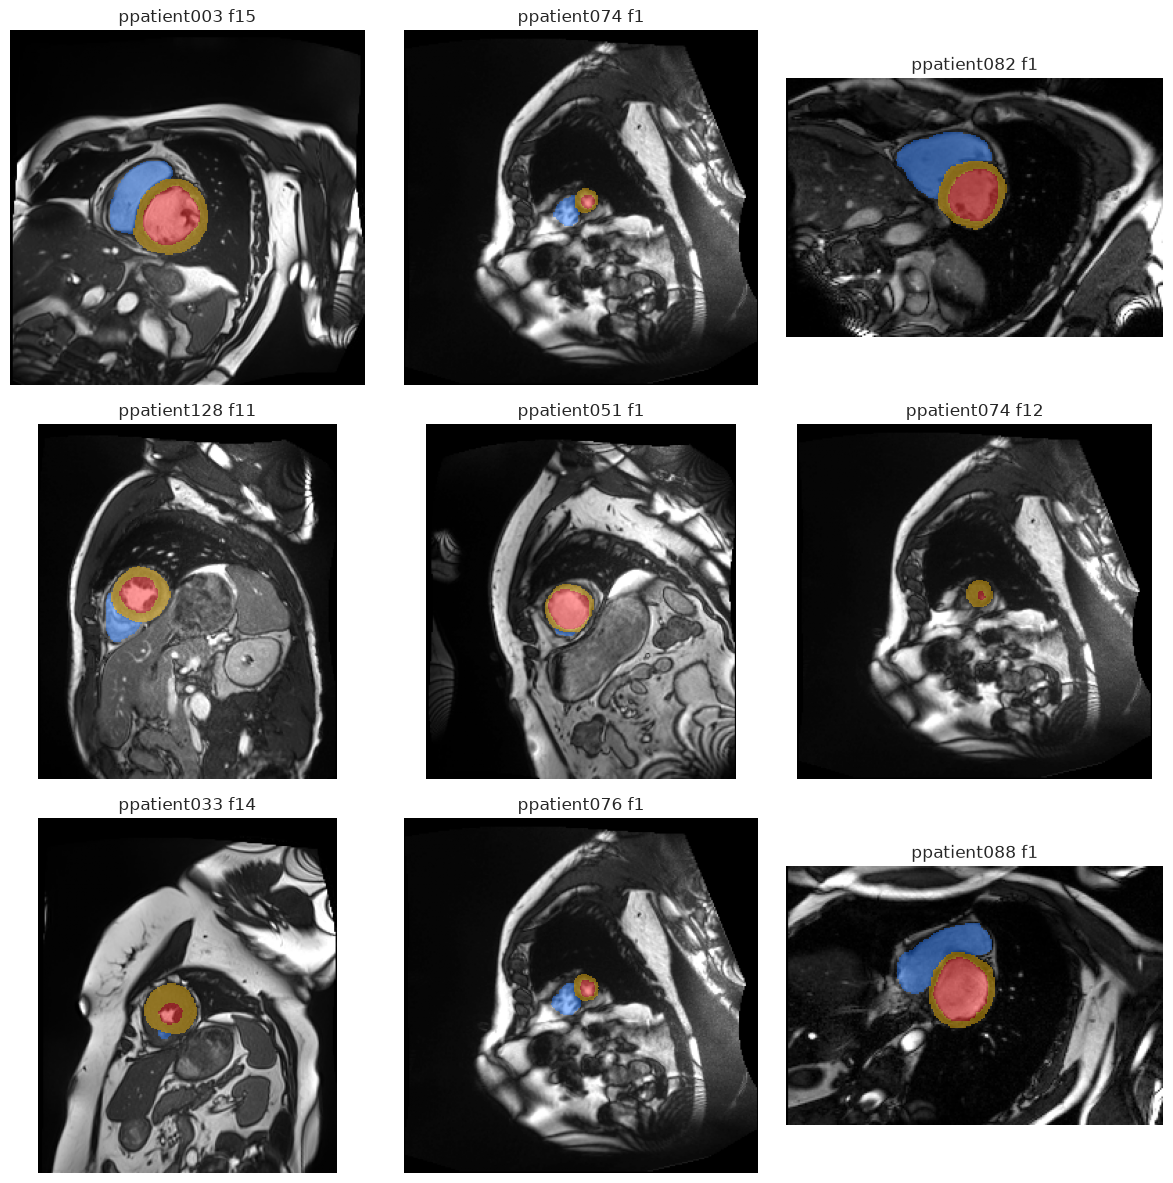

In [21]:
if manifest.empty or "has_label" not in manifest:
    print("No labeled files available for montage.")
else:
    labeled = manifest[manifest["has_label"].fillna(False)].copy()
    if labeled.empty:
        print("No labeled files available for montage.")
    else:
        sample = labeled.sample(min(9, len(labeled)), random_state=7)
        fig, axes = plt.subplots(3, 3, figsize=(12, 12))
        for ax, row in zip(axes.ravel(), sample.itertuples()):
            image, label, attrs = load_image_label(row.path)
            idx = image.shape[0] // 2 if image.ndim == 3 else None
            image2d = slice_2d(image, idx)
            label2d = slice_2d(label, idx)
            ax.imshow(normalize_for_display(image2d), cmap="gray")
            if label2d is not None:
                ax.imshow(LABEL_COLORS[np.clip(label2d.astype(int), 0, len(LABEL_COLORS) - 1)], interpolation="nearest")
            title = f"p{row.patient_id} f{row.frame}"
            if image.ndim == 3:
                title += f" z{idx}"
            ax.set_title(title)
            ax.axis("off")
        for ax in axes.ravel()[len(sample):]:
            ax.axis("off")
        plt.tight_layout()


## Final Pass/Fail Summary

In [22]:
if manifest.empty:
    print("FAIL: No HDF5 files found at DATA_ROOT.")
else:
    checks = []
    checks.append(("all files readable", not manifest["issues"].str.contains("failed to read", regex=False).any()))
    checks.append(("all files have image dataset", not manifest["issues"].str.contains("missing dataset: image", regex=False).any()))
    checks.append(("all files have spacing metadata", bool(manifest["has_spacing"].all())))
    checks.append(("all spacing values positive finite", not manifest["issues"].str.contains("spacing must be positive", regex=False).any()))
    if "has_label" in manifest and manifest["has_label"].fillna(False).any():
        checks.append(("all labels match image shape", not manifest["issues"].str.contains("label shape does not match", regex=False).any()))
        checks.append(("all label values are in 0..3", not manifest["issues"].str.contains("unexpected label values", regex=False).any()))
    checks.append(("all images finite", not manifest["issues"].str.contains("image contains NaN or Inf", regex=False).any()))

    result = pd.DataFrame(checks, columns=["check", "passed"])
    display(result)
    if result["passed"].all():
        print("PASS: No blocking dataset validity issues found by this notebook.")
    else:
        print("FAIL: One or more dataset validity checks failed. Inspect the issue table above.")


,check,passed
0,all files readable,True
1,all files have image dataset,True
2,all files have spacing metadata,True
3,all spacing values positive finite,True
4,all labels match image shape,True
5,all label values are in 0..3,True
6,all images finite,True


PASS: No blocking dataset validity issues found by this notebook.
